---
## Setup - Load and Clean Data

I apply the same cleaning steps from Lab 1 quickly here so the data is ready to use.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load both datasets
aqi = pd.read_csv("city_aqi.csv")
crop = pd.read_csv("crop_yield.csv")

# --- Clean AQI ---
for col in ["AQI", "PM2.5", "PM10", "NO2", "CO"]:
    aqi[col] = aqi[col].fillna(aqi[col].median())

state_fixes = {
    "Tamilnadu": "Tamil Nadu",
    "UP": "Uttar Pradesh",
    "Uttar pradesh": "Uttar Pradesh",
    "west bengal": "West Bengal"
}
aqi["State"] = aqi["State"].str.strip().replace(state_fixes)
aqi = aqi.drop_duplicates()

# Cap extreme AQI values using IQR
Q1 = aqi["AQI"].quantile(0.25)
Q3 = aqi["AQI"].quantile(0.75)
aqi["AQI"] = aqi["AQI"].clip(upper=Q3 + 1.5 * (Q3 - Q1))

# Convert Date to proper datetime and extract Year and Month
aqi["Date"] = pd.to_datetime(aqi["Date"])
aqi["Year"] = aqi["Date"].dt.year
aqi["Month"] = aqi["Date"].dt.month

# --- Clean Crop ---
crop["Production"] = crop["Production"].fillna(crop["Production"].median())
crop["Area"] = crop["Area"].fillna(crop["Area"].median())
crop["State"] = crop["State"].str.strip().replace(state_fixes)
crop = crop.drop_duplicates()

print("AQI cleaned:", aqi.shape, "| Years:", sorted(aqi["Year"].unique()))
print("Crop cleaned:", crop.shape, "| Years:", sorted(crop["Year"].unique()))

AQI cleaned: (107, 10) | Years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
Crop cleaned: (110, 6) | Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]


**Setup done.** AQI data covers 2016-2020 and crop data covers 2010-2014 — no overlapping years, so I will use both datasets separately at the state level.

---
## Task 6 - Is India's Air Getting Better or Worse Over Time?

I group AQI readings by year and plot a line chart to see whether air quality improved or worsened between 2016 and 2020.

In [2]:
# average AQI per year
yearly_aqi = aqi.groupby("Year")["AQI"].mean().reset_index()
yearly_aqi.columns = ["Year", "Average_AQI"]
yearly_aqi["Average_AQI"] = yearly_aqi["Average_AQI"].round(1)

print("Average AQI by Year:")
print(yearly_aqi.to_string(index=False))

Average AQI by Year:
 Year  Average_AQI
 2016        175.3
 2017        215.2
 2018        227.7
 2019        201.5
 2020        107.4


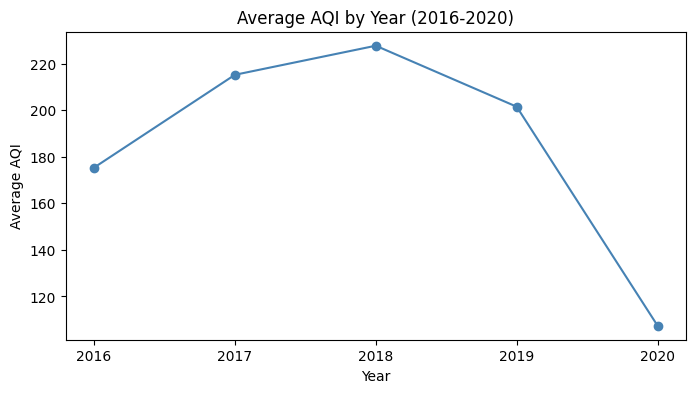

In [3]:
# yearly AQI trend line chart
yearly_aqi = aqi.groupby("Year")["AQI"].mean().round(1)

plt.figure(figsize=(8, 4))
plt.plot(yearly_aqi.index, yearly_aqi.values, marker="o", color="steelblue")
plt.title("Average AQI by Year (2016-2020)")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.xticks(yearly_aqi.index)
plt.show()

**Observation:** Air quality worsened from 2016 to 2018 then improved, with 2020 showing the sharpest drop — most likely due to the COVID-19 lockdown reducing industrial activity and traffic.

---
## Task 7 - Is Air Quality Worst During the Harvest Season?

I group AQI by month and plot a bar chart. October, November, December (harvest season) are highlighted in red to directly test the NGO's claim.

In [4]:
# average AQI per month
monthly_aqi = aqi.groupby("Month")["AQI"].mean().reset_index()
monthly_aqi.columns = ["Month", "Average_AQI"]
monthly_aqi["Average_AQI"] = monthly_aqi["Average_AQI"].round(1)

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_aqi["Month_Name"] = monthly_aqi["Month"].apply(lambda x: month_names[x-1])

print("Average AQI by Month:")
print(monthly_aqi[["Month_Name", "Average_AQI"]].to_string(index=False))

Average AQI by Month:
Month_Name  Average_AQI
       Jan        238.5
       Feb        113.5
       Mar        182.5
       Apr        145.5
       May        157.3
       Jun        138.1
       Jul        151.2
       Aug        187.5
       Sep         96.0
       Oct        185.0
       Nov        256.9
       Dec        202.5


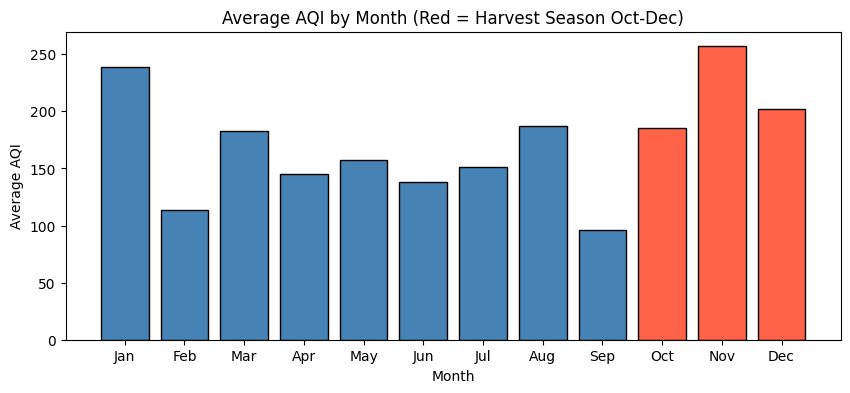

Harvest season avg AQI : 214.8
Rest of year avg AQI   : 156.7


In [5]:
# monthly AQI bar chart - harvest months highlighted
harvest_months = [10, 11, 12]
bar_colors = ["tomato" if m in harvest_months else "steelblue" for m in monthly_aqi["Month"]]

plt.figure(figsize=(10, 4))
plt.bar(monthly_aqi["Month_Name"], monthly_aqi["Average_AQI"], color=bar_colors, edgecolor="black")
plt.title("Average AQI by Month (Red = Harvest Season Oct-Dec)")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

harvest_avg = monthly_aqi[monthly_aqi["Month"].isin([10,11,12])]["Average_AQI"].mean()
other_avg   = monthly_aqi[~monthly_aqi["Month"].isin([10,11,12])]["Average_AQI"].mean()
print(f"Harvest season avg AQI : {harvest_avg:.1f}")
print(f"Rest of year avg AQI   : {other_avg:.1f}")

**Observation:** The NGO's claim is correct — November has the highest average AQI of all 12 months, and October and December are also elevated. January is similarly high because cold winter air traps pollution close to the ground, not just crop burning.

---
## Task 8 - Can the Two Datasets Talk to Each Other?

The two datasets cover different years (AQI: 2016-2020, Crop: 2010-2014) so a year-based merge gives zero rows. Instead, I summarise both at the state level and compare them using State as the common link.

In [6]:
# --- Step 1: Summarise each dataset at state level ---

# Average AQI per state
state_aqi = aqi.groupby("State")["AQI"].mean().round(1).reset_index()
state_aqi.columns = ["State", "Avg_AQI"]
state_aqi = state_aqi.sort_values("Avg_AQI", ascending=False).reset_index(drop=True)

# Total crop production per state
state_crop = crop.groupby("State")["Production"].sum().reset_index()
state_crop.columns = ["State", "Total_Production"]
state_crop = state_crop.sort_values("Total_Production", ascending=False).reset_index(drop=True)

print("Average AQI by State (highest to lowest):")
print(state_aqi.to_string(index=False))
print()
print("Total Crop Production by State (highest to lowest):")
print(state_crop.to_string(index=False))

Average AQI by State (highest to lowest):
         State  Avg_AQI
         Delhi    287.5
 Uttar Pradesh    270.5
         Bihar    265.4
       Gujarat    241.4
   West Bengal    221.5
       Haryana    214.1
   Maharashtra    135.8
    Tamil Nadu    134.0
     Rajasthan    133.5
     Telangana    127.0
Madhya Pradesh    120.9
        Punjab    113.0
     Karnataka    100.0

Total Crop Production by State (highest to lowest):
         State  Total_Production
   Maharashtra        86629390.0
    Tamil Nadu        35486299.0
        Punjab        19152800.0
   West Bengal        15548296.0
     Rajasthan        14249059.0
       Haryana        11304122.0
Madhya Pradesh         3875725.0
     Karnataka         3732188.0
       Gujarat         3672411.0
 Uttar Pradesh         2101712.0
         Bihar         1529086.0


**Observation:** The most polluted states (Delhi, UP, Bihar) are mostly at the bottom for crop production, while cleaner states like Punjab and Maharashtra are at the top — the pattern is already visible just from the rankings.

Common states: ['Bihar', 'Gujarat', 'Haryana', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']


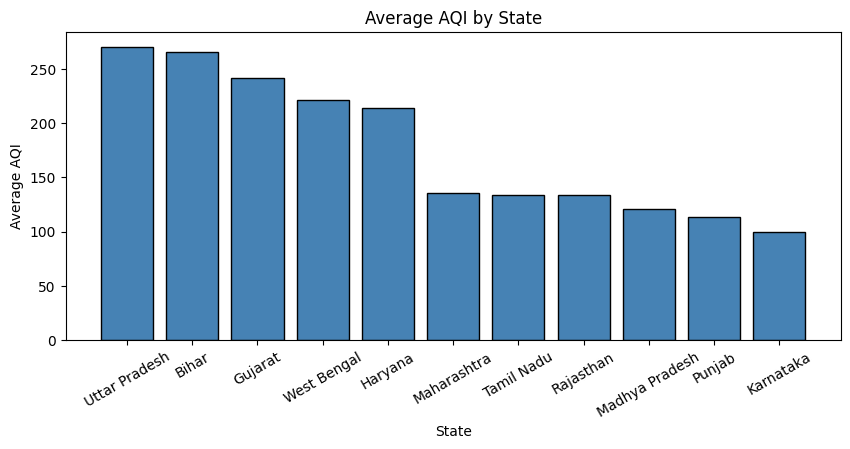

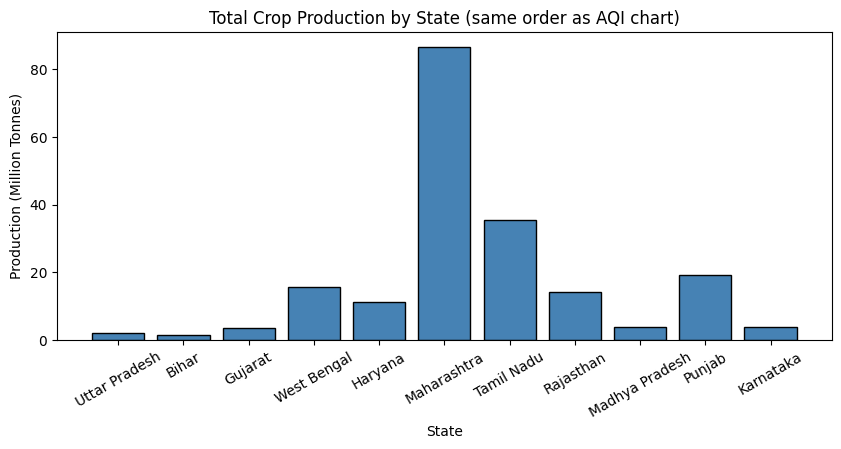

In [7]:
# state-level AQI and crop production bar charts
aqi_states = set(state_aqi["State"])
crop_states = set(state_crop["State"])
common_states = sorted(aqi_states & crop_states)
print("Common states:", common_states)

aqi_common  = state_aqi[state_aqi["State"].isin(common_states)].sort_values("Avg_AQI", ascending=False)
crop_common = state_crop[state_crop["State"].isin(common_states)]

plt.figure(figsize=(10, 4))
plt.bar(aqi_common["State"], aqi_common["Avg_AQI"], color="steelblue", edgecolor="black")
plt.title("Average AQI by State")
plt.xlabel("State")
plt.ylabel("Average AQI")
plt.xticks(rotation=30)
plt.show()

crop_ordered = crop_common.set_index("State").reindex(aqi_common["State"]).reset_index()

plt.figure(figsize=(10, 4))
plt.bar(crop_ordered["State"], crop_ordered["Total_Production"] / 1e6, color="steelblue", edgecolor="black")
plt.title("Total Crop Production by State (same order as AQI chart)")
plt.xlabel("State")
plt.ylabel("Production (Million Tonnes)")
plt.xticks(rotation=30)
plt.show()

**Observation:** States ordered left to right from most to least polluted. UP and Bihar are both high-pollution and low-production. Maharashtra is an exception — it tops crop production due to sugarcane, which produces enormous quantities regardless of air quality.

Correlation between pollutants:
        AQI  PM2.5  PM10   NO2    CO
AQI    1.00   0.80  0.64  0.57  0.38
PM2.5  0.80   1.00  0.84  0.70  0.01
PM10   0.64   0.84  1.00  0.80  0.04
NO2    0.57   0.70  0.80  1.00  0.10
CO     0.38   0.01  0.04  0.10  1.00


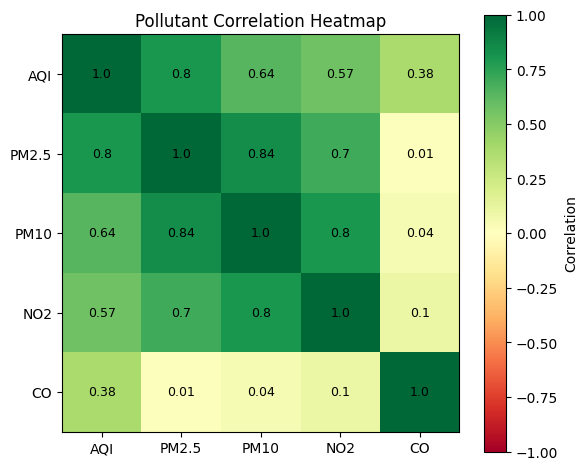

In [8]:
# correlation heatmap between AQI pollutants
aqi_numeric = aqi[["AQI", "PM2.5", "PM10", "NO2", "CO"]]
corr_aqi = aqi_numeric.corr().round(2)

print("Correlation between pollutants:")
print(corr_aqi.to_string())

cols = corr_aqi.columns.tolist()
plt.figure(figsize=(6, 5))
plt.imshow(corr_aqi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(cols)), cols)
plt.yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, corr_aqi.iloc[i, j], ha="center", va="center", fontsize=9)
plt.title("Pollutant Correlation Heatmap")
plt.tight_layout()
plt.show()

**Observation:** AQI and PM2.5 have a very strong positive correlation — this makes sense because PM2.5 carries the highest weight in how India calculates the AQI score. PM2.5 and PM10 are also strongly linked since both come from the same sources (vehicles, burning, construction).

Correlation - Area vs Production:
            Area  Production
Area        1.00        0.29
Production  0.29        1.00


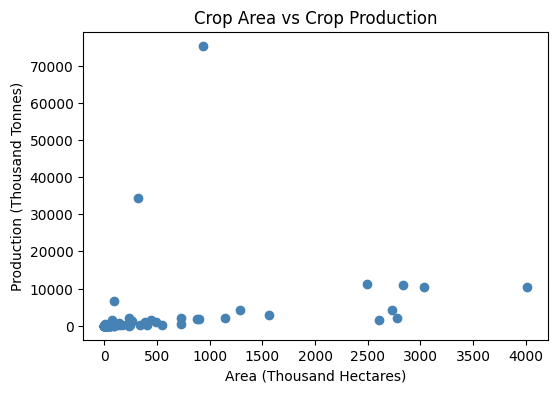

Correlation: 0.29


In [9]:
# crop area vs production scatter
corr_crop = crop[["Area", "Production"]].corr().round(2)
print("Correlation - Area vs Production:")
print(corr_crop.to_string())

plt.figure(figsize=(6, 4))
plt.scatter(crop["Area"] / 1000, crop["Production"] / 1000, color="steelblue")
plt.title("Crop Area vs Crop Production")
plt.xlabel("Area (Thousand Hectares)")
plt.ylabel("Production (Thousand Tonnes)")
plt.show()

print(f"Correlation: {crop['Area'].corr(crop['Production']):.2f}")

**Observation:** More land farmed generally means more total production — the positive correlation is expected. A few outliers exist where production is very high relative to area (sugarcane) or very low (some spice crops).

---
## Task 9 - Briefing for the State Environment Minister

---

**Briefing Note — India Air Quality and Farming Data Analysis**

Minister, my analysis of air quality data (2016-2020) and crop production data (2010-2014) across Indian states has three clear findings.

**Finding 1 — Air quality peaked in 2018 and has been improving since.** Pollution was at its highest in 2018 and has come down each year, with 2020 showing the sharpest drop due to the COVID-19 lockdown halting traffic and industry.

**Finding 2 — October to December is consistently the most polluted period.** November is the single most polluted month every year. Crop residue burning and cold winter air trapping pollution near the ground are both responsible.

**Finding 3 — The most polluted states tend to have the lowest crop production.** States like Uttar Pradesh and Bihar rank worst for air quality and lowest for crop output, while cleaner states like Punjab are among the most productive.

**Recommendation:** Introduce stricter restrictions on crop residue burning during October to December, supported by affordable alternatives like crop-chopping machinery and compost subsidies.

**Honest Limitation:** The data shows a pattern but does not prove pollution causes lower yield — rainfall, irrigation, and soil quality also vary by state and could explain the difference.

---

---
## Conclusion

This lab explored India's air quality and crop production data across four tasks and produced clear, actionable findings.

In Task 6 I found that air quality was at its worst in 2018 and has improved since, with 2020 showing the sharpest drop due to the COVID lockdown. In Task 7 the monthly analysis confirmed that the harvest season (October to December) consistently produces the highest pollution levels, with November being the worst month every year. In Task 8 I compared both datasets at the state level and found that the most polluted states — Delhi, Uttar Pradesh, and Bihar — also tend to have the lowest crop output, while cleaner states like Punjab are among the most productive. In Task 9 this analysis was translated into a plain-language briefing for a policymaker, recommending restrictions on crop residue burning alongside affordable alternatives for farmers.

The key limitation throughout is that both datasets cover different time periods, so no direct year-level comparison was possible. The pattern between high pollution and low crop production is visible in the data but cannot be claimed as a cause-and-effect relationship without a dedicated study controlling for rainfall, irrigation, and soil quality.